In [ ]:
import os
import random
import torch
import torchaudio
import numpy as np
import pandas as pd
import umap
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from IPython.display import Audio, display

load audio

In [ ]:
def load_audio(path, sr=16000):

    waveform, sample_rate = torchaudio.load(path)

    if sample_rate != sr:
        waveform = torchaudio.functional.resample(waveform, sample_rate, sr)

    waveform = waveform.mean(dim=0, keepdim=True)

    return waveform

extract spectrogram patches

In [ ]:
def extract_patches(spec, pf=16, pt=8, stride=4):

    F, T = spec.shape
    patches = []

    if F < pf or T < pt:
        return None

    for f in range(0, F - pf + 1, stride):
        for t in range(0, T - pt + 1, stride):

            patch = spec[f:f+pf, t:t+pt]
            patches.append(patch.flatten())

    if len(patches) == 0:
        return None

    return torch.stack(patches)

k-means

In [ ]:
def run_kmeans_pipeline(folder, title, class_lookup=None):

    mel = torchaudio.transforms.MelSpectrogram(
        sample_rate=16000,
        n_fft=512,
        hop_length=128,
        n_mels=64
    )

    patches_all = []
    patch_classes = []

    files = [f for f in os.listdir(folder) if f.endswith(".wav") or f.endswith(".flac")]
    np.random.shuffle(files)

    for file in files:

        path = os.path.join(folder, file)

        try:
            audio = load_audio(path)
        except:
            continue

        spec = torch.log(mel(audio) + 1e-6).squeeze(0)
        file_patches = extract_patches(spec)

        if file_patches is None:
            continue

        patches_all.append(file_patches)

        if class_lookup and file in class_lookup:
            cls = class_lookup[file]
        else:
            cls = "unknown"

        patch_classes += [cls] * len(file_patches)

    patches = torch.cat(patches_all).numpy()

    # random balanced sampling
    np.random.seed(0)
    n = min(12000, len(patches))
    idx = np.random.choice(len(patches), n, replace=False)

    patches = patches[idx]
    patch_classes = [patch_classes[i] for i in idx]
    if not class_lookup == None:
      from collections import defaultdict
      import random

      # group patches by class
      class_patches = defaultdict(list)

      for p, c in zip(patches, patch_classes):
          class_patches[c].append(p)

      balanced_patches = []
      balanced_classes = []

      samples_per_class = 400

      for c in class_patches:

          patches_c = class_patches[c]

          if len(patches_c) < samples_per_class:
              continue

          chosen = random.sample(patches_c, samples_per_class)

          balanced_patches.extend(chosen)
          balanced_classes.extend([c]*samples_per_class)

      patches = np.array(balanced_patches)
      patch_classes = balanced_classes
    # KMeans
    kmeans = KMeans(n_clusters=10, random_state=0)
    labels = kmeans.fit_predict(patches)

    # PCA visualization
    pca = PCA(n_components=2)
    embedded = pca.fit_transform(patches)

    # cluster plot
    plt.figure(figsize=(7,6))
    plt.scatter(embedded[:,0], embedded[:,1], c=labels, cmap="tab10", alpha=0.5)
    plt.title(title + " (K-Means Clusters)")
    plt.xlabel("Dim 1")
    plt.ylabel("Dim 2")
    plt.show()

    # class plot
    if class_lookup:
        unique_classes = list(set(patch_classes))
        class_to_idx = {c:i for i,c in enumerate(unique_classes)}
        colors = [class_to_idx[c] for c in patch_classes]

        plt.figure(figsize=(7,6))
        plt.scatter(embedded[:,0], embedded[:,1], c=colors, cmap="tab10", alpha=0.5)
        plt.title(title + " (Colored by Class)")
        plt.xlabel("Dim 1")
        plt.ylabel("Dim 2")
        plt.show()

load labels

In [ ]:
metadata = pd.read_csv("/content/UrbanSound8K.csv")

class_lookup = dict(
    zip(metadata["slice_file_name"], metadata["class"])
)

run


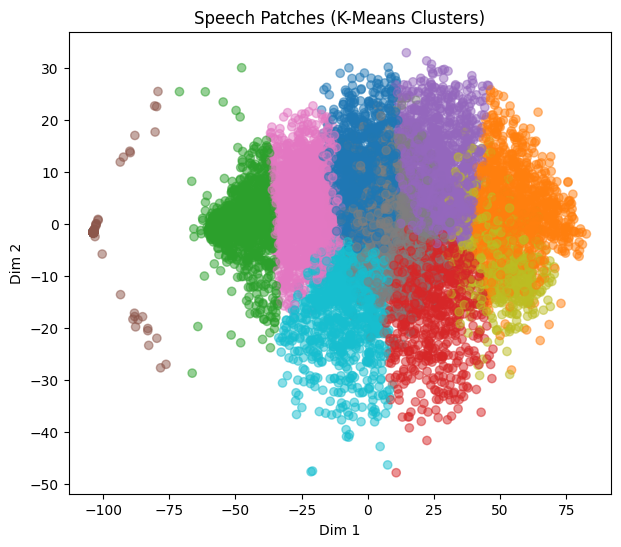

In [ ]:
run_kmeans_pipeline("/content/121123", "Speech Patches")

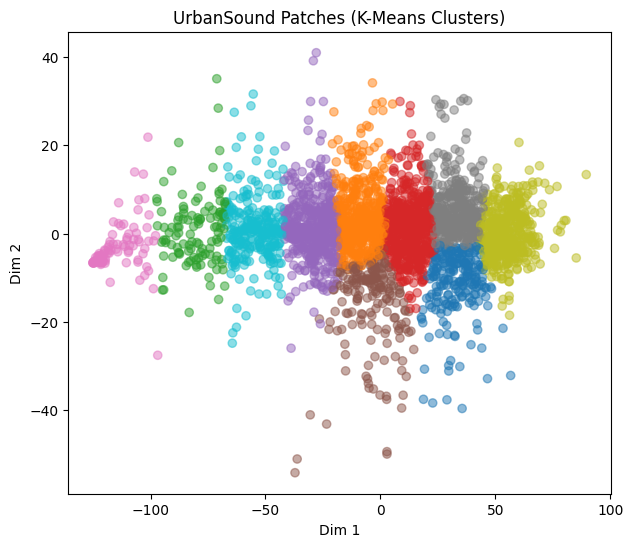

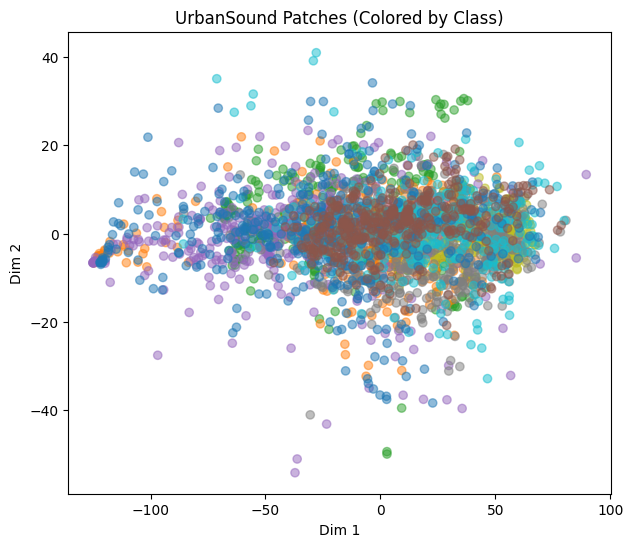

In [ ]:
metadata = pd.read_csv("/content/UrbanSound8K.csv")
class_lookup = dict(zip(metadata["slice_file_name"], metadata["class"]))

run_kmeans_pipeline("/content/fold1", "UrbanSound Patches", class_lookup)

In [ ]:
from IPython.display import Audio, display
import random
import os
import torchaudio

urban_files = [
    f for f in os.listdir("/content/fold1")
    if f.endswith(".wav") or f.endswith(".flac")
]

files = random.sample(urban_files, 5)

for f in files:
    print("File:", f)
    print("Class:", class_lookup.get(f, "unknown"))

    path = os.path.join("/content/fold1", f)
    waveform, sr = torchaudio.load(path)

    display(Audio(waveform.numpy(), rate=sr))

File: 24074-1-0-7.wav
Class: car_horn


File: 174290-6-0-0.wav
Class: gun_shot


File: 46669-4-0-0.wav
Class: drilling


File: 196065-2-0-0.wav
Class: children_playing


File: 159738-8-0-1.wav
Class: siren
